In [2]:
from PPOClip_Completo import PPO_Clip_Completo
from PPOClip_basic import PPO_Clip_Basic
from PPOClip_entropy import PPO_Clip_Entropy
from PPOClip_GAE import PPO_Clip_GAE
from PPOClip_Annealing import PPO_Clip_Annealing

from ValueNet import ValueNet
from PolicyNet import PolicyNet
import matplotlib.pyplot as plt 
import torch
import flappy_bird_gymnasium
import gymnasium
import numpy as np

# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# print(f"Using device: {device}")
# device = "cpu"  



/Users/mateocostantini/Library/Python/3.9/lib/python/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [3]:
def plot_metrics(modelo_entrenado, hiperparams):
    reward = torch.load(f"trained_net/{modelo_entrenado}/metrics.pt")["rewards"]
    plt.plot(np.linspace(0, hiperparams["epochs"], len(reward)),reward)
    plt.title("Recompensa entrenamiento")
    plt.show()

    entropy = torch.load(f"trained_net/{modelo_entrenado}/metrics.pt")["entropy"]
    if entropy is not None:
        plt.plot(np.linspace(0, hiperparams["epochs"], len(entropy)),entropy)
        plt.title("Entropía entrenamiento")
        plt.show()

    loss = torch.load(f"trained_net/{modelo_entrenado}/metrics.pt")["loss"]
    plt.plot(np.linspace(0, hiperparams["epochs"], len(loss)),loss)
    plt.title("Loss entrenamiento")
    plt.show()

## Environment

In [2]:

env = gymnasium.make("FlappyBird-v0", use_lidar=False)
print(f"Action Dim: {env.action_space.n}")
print(f"Obs Dim: {env.observation_space}")

Action Dim: 2
Obs Dim: Box(-1.0, 1.0, (12,), float64)


In [3]:
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)



In [ ]:
hiperparams = {
    "epochs": 50, #dejar 1500,
    "K": 80,
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.0001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 60000
    
}

## Basic

Epoch 1/50 -- reward: 596.50
Guardando modelos...
Epoch 2/50 -- reward: 680.10
Guardando modelos...
Epoch 3/50 -- reward: 660.00
Epoch 4/50 -- reward: 697.60
Guardando modelos...
Epoch 5/50 -- reward: 699.30
Guardando modelos...
Epoch 6/50 -- reward: 700.80
Guardando modelos...
Epoch 7/50 -- reward: 674.90
Epoch 8/50 -- reward: 775.50
Guardando modelos...
Epoch 9/50 -- reward: 812.60
Guardando modelos...
Epoch 10/50 -- reward: 792.00
Epoch 11/50 -- reward: 808.60
Epoch 12/50 -- reward: 883.60
Guardando modelos...
Epoch 13/50 -- reward: 855.00
Epoch 14/50 -- reward: 836.90
Epoch 15/50 -- reward: 879.40
Epoch 16/50 -- reward: 916.40
Guardando modelos...
Epoch 17/50 -- reward: 903.20
Epoch 18/50 -- reward: 925.90
Guardando modelos...
Epoch 19/50 -- reward: 1064.00
Guardando modelos...
Epoch 20/50 -- reward: 1136.30
Guardando modelos...
Epoch 21/50 -- reward: 1036.70
Epoch 22/50 -- reward: 1186.40
Guardando modelos...
Epoch 23/50 -- reward: 1242.90
Guardando modelos...
Epoch 24/50 -- rewar

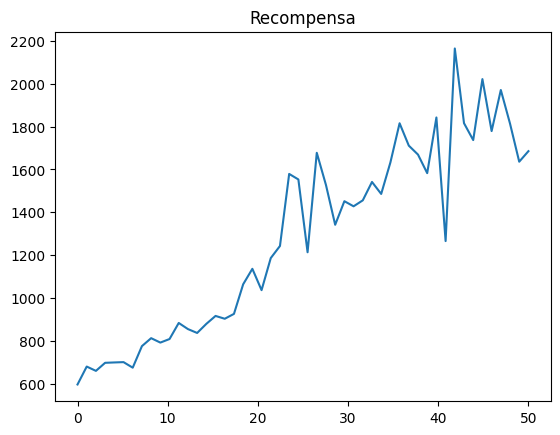

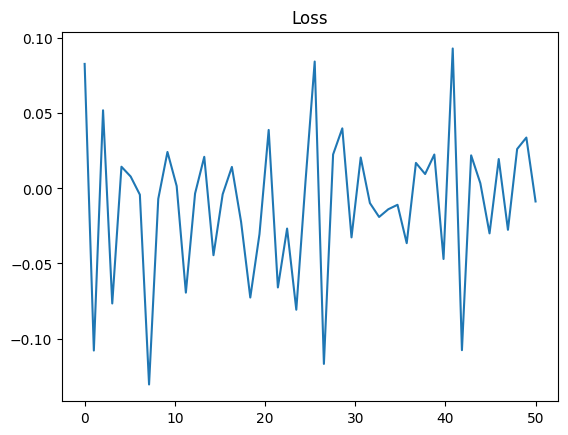

In [ ]:
modelo_entrenado = "PPO_Clip_Basic v1"
PPO = PPO_Clip_Basic(hiperparams )
save_policy_file = f"trained_net/{modelo_entrenado}/flappy_actor.pth"
save_value_file = f"trained_net/{modelo_entrenado}/flappy_critic.pth"
save_metric_file = f"trained_net/{modelo_entrenado}/metrics.pt"
rewards, loss, entropy = PPO.train(env, save_file_policy=save_policy_file, save_file_value=save_value_file, save_metrics_file=save_metric_file)
plot_metrics(modelo_entrenado, hiperparams)


In [ ]:
modelo_entrenado = "PPO_Clip_Basic v1"
env = gymnasium.make("FlappyBird-v0", render_mode="human", use_lidar=False)
PPO = PPO_Clip_Basic(hiperparams )
plot_metrics(modelo_entrenado, hiperparams) 

policy_net = PolicyNet(12, 2)

policy_net.load_state_dict(torch.load(f"trained_net/{modelo_entrenado}/flappy_actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 5)
env.close()



reward: 36.40000000000021 en 312 pasos
reward: 12.899999999999974 en 122 pasos
reward: 26.90000000000011 en 235 pasos
reward: 12.899999999999974 en 122 pasos
reward: 8.399999999999986 en 86 pasos


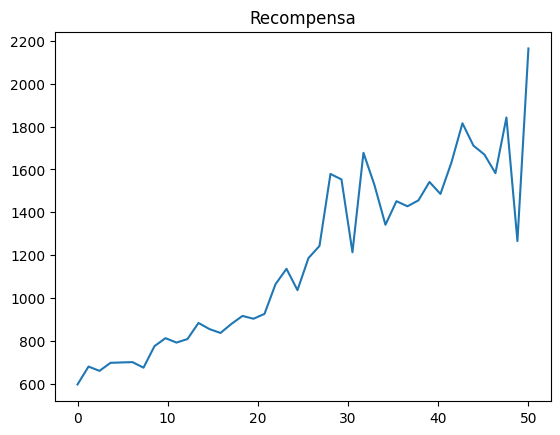

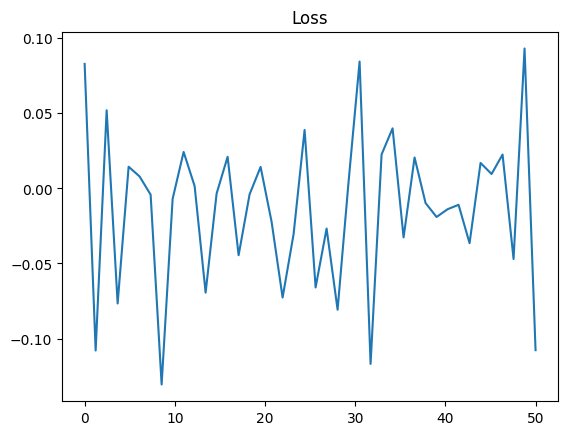

## GAE

In [4]:
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)
hiperparams = {
    "epochs": 50, #dejar 1500,
    "K": 80,
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.0001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 60000
    
}

In [ ]:
modelo_entrenado = "PPO_Clip_GAE v1"
PPO = PPO_Clip_Basic(hiperparams )
save_policy_file = f"trained_net/{modelo_entrenado}/flappy_actor.pth"
save_value_file = f"trained_net/{modelo_entrenado}/flappy_critic.pth"
save_metric_file = f"trained_net/{modelo_entrenado}/metrics.pt"
rewards, loss, entropy = PPO.train(env, save_file_policy=save_policy_file, save_file_value=save_value_file, save_metrics_file=save_metric_file)
plot_metrics(modelo_entrenado, hiperparams)


error: video system not initialized

: 

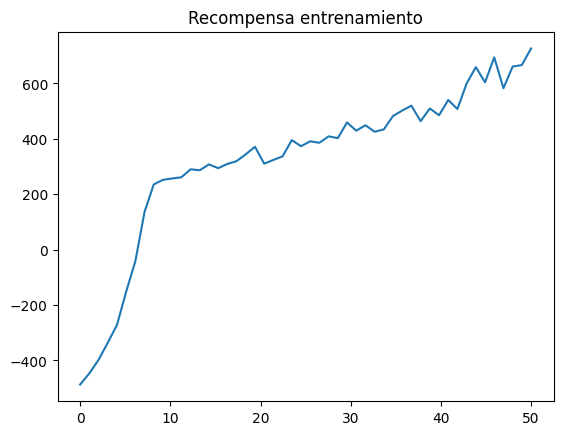

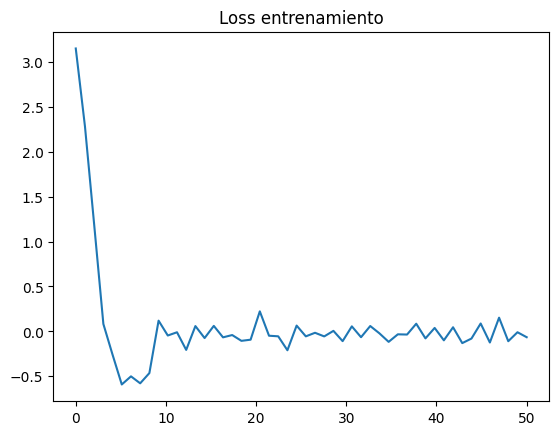

reward: 12.899999999999974 en 122 pasos
reward: 8.499999999999986 en 87 pasos
reward: 8.899999999999984 en 91 pasos


In [5]:
modelo_entrenado = "PPO_Clip_GAE v1"
env = gymnasium.make("FlappyBird-v0", render_mode="human", use_lidar=False)
PPO = PPO_Clip_Basic(hiperparams )
plot_metrics(modelo_entrenado, hiperparams) 

policy_net = PolicyNet(12, 2)

policy_net.load_state_dict(torch.load(f"trained_net/{modelo_entrenado}/flappy_actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()



## Entropy

In [6]:
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)
hiperparams = {
    "epochs": 50, #dejar 1500,
    "K": 80,
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.0001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 60000
    
}

Epoch 1/50 -- reward: -481.20
Guardando modelos...
Epoch 2/50 -- reward: -409.80
Guardando modelos...
Epoch 3/50 -- reward: -358.20
Guardando modelos...
Epoch 4/50 -- reward: -309.60
Guardando modelos...
Epoch 5/50 -- reward: -226.00
Guardando modelos...
Epoch 6/50 -- reward: -32.90
Guardando modelos...
Epoch 7/50 -- reward: 116.20
Guardando modelos...
Epoch 8/50 -- reward: 205.50
Guardando modelos...
Epoch 9/50 -- reward: 228.60
Guardando modelos...
Epoch 10/50 -- reward: 260.40
Guardando modelos...
Epoch 11/50 -- reward: 255.90
Epoch 12/50 -- reward: 286.60
Guardando modelos...
Epoch 13/50 -- reward: 292.90
Guardando modelos...
Epoch 14/50 -- reward: 297.40
Guardando modelos...
Epoch 15/50 -- reward: 308.20
Guardando modelos...
Epoch 16/50 -- reward: 303.20
Epoch 17/50 -- reward: 354.10
Guardando modelos...
Epoch 18/50 -- reward: 347.40
Epoch 19/50 -- reward: 346.90
Epoch 20/50 -- reward: 313.10
Epoch 21/50 -- reward: 329.80
Epoch 22/50 -- reward: 364.70
Guardando modelos...
Epoch 23

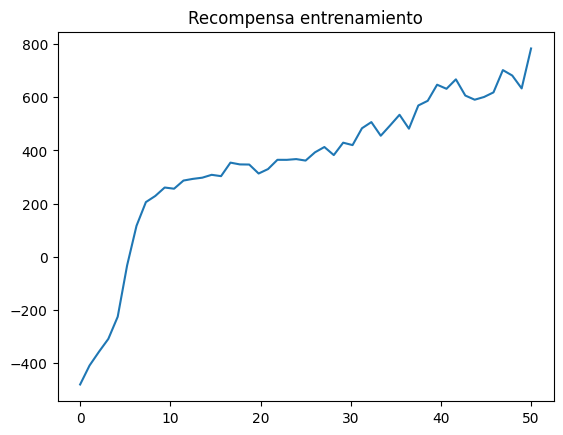

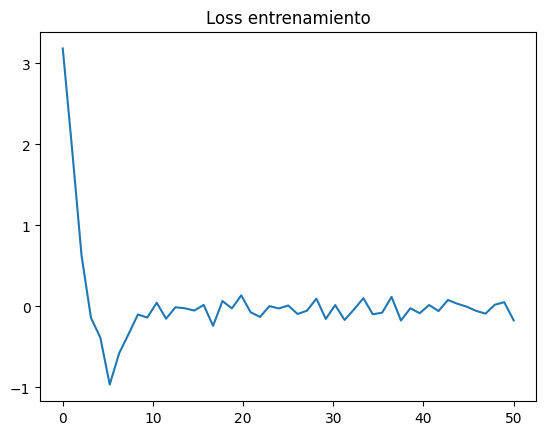

In [7]:
modelo_entrenado = "PPO_Clip_Entropy v1"
PPO = PPO_Clip_Basic(hiperparams )
save_policy_file = f"trained_net/{modelo_entrenado}/flappy_actor.pth"
save_value_file = f"trained_net/{modelo_entrenado}/flappy_critic.pth"
save_metric_file = f"trained_net/{modelo_entrenado}/metrics.pt"
rewards, loss, entropy = PPO.train(env, save_file_policy=save_policy_file, save_file_value=save_value_file, save_metrics_file=save_metric_file)
plot_metrics(modelo_entrenado, hiperparams)


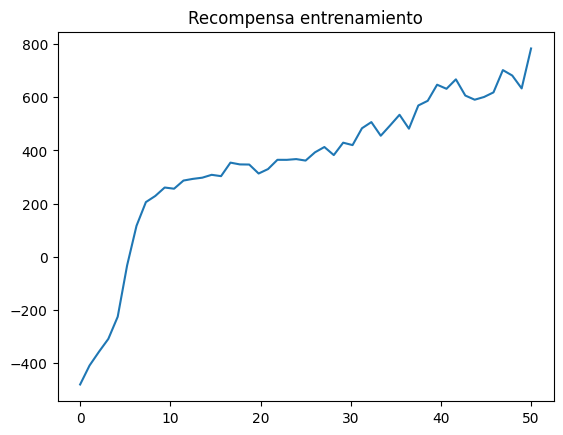

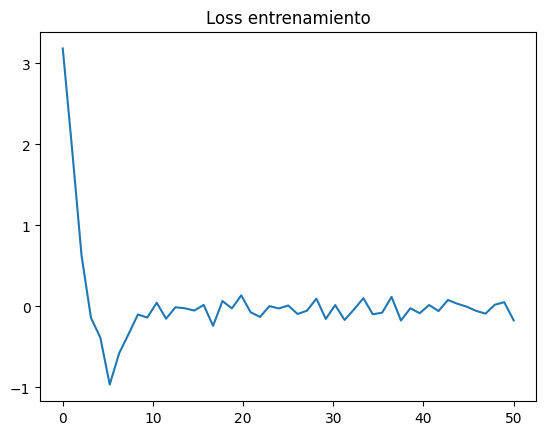

reward: 17.90000000000001 en 163 pasos
reward: 13.79999999999997 en 131 pasos
reward: 13.599999999999971 en 129 pasos


In [8]:
modelo_entrenado = "PPO_Clip_Entropy v1"
env = gymnasium.make("FlappyBird-v0", render_mode="human", use_lidar=False)
PPO = PPO_Clip_Basic(hiperparams )
plot_metrics(modelo_entrenado, hiperparams) 

policy_net = PolicyNet(12, 2)

policy_net.load_state_dict(torch.load(f"trained_net/{modelo_entrenado}/flappy_actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()



## LR Annealing

In [9]:
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)
hiperparams = {
    "epochs": 50, #dejar 1500,
    "K": 80,
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.0001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 60000
    
}

Epoch 1/50 -- reward: -457.20
Guardando modelos...
Epoch 2/50 -- reward: -416.40
Guardando modelos...
Epoch 3/50 -- reward: -369.60
Guardando modelos...
Epoch 4/50 -- reward: -348.60
Guardando modelos...
Epoch 5/50 -- reward: -206.30
Guardando modelos...
Epoch 6/50 -- reward: -31.50
Guardando modelos...
Epoch 7/50 -- reward: 142.30
Guardando modelos...
Epoch 8/50 -- reward: 185.80
Guardando modelos...
Epoch 9/50 -- reward: 228.50
Guardando modelos...
Epoch 10/50 -- reward: 241.10
Guardando modelos...
Epoch 11/50 -- reward: 271.40
Guardando modelos...
Epoch 12/50 -- reward: 255.00
Epoch 13/50 -- reward: 279.20
Guardando modelos...
Epoch 14/50 -- reward: 286.90
Guardando modelos...
Epoch 15/50 -- reward: 283.00
Epoch 16/50 -- reward: 302.90
Guardando modelos...
Epoch 17/50 -- reward: 304.70
Guardando modelos...
Epoch 18/50 -- reward: 316.30
Guardando modelos...
Epoch 19/50 -- reward: 332.50
Guardando modelos...
Epoch 20/50 -- reward: 334.80
Guardando modelos...
Epoch 21/50 -- reward: 307

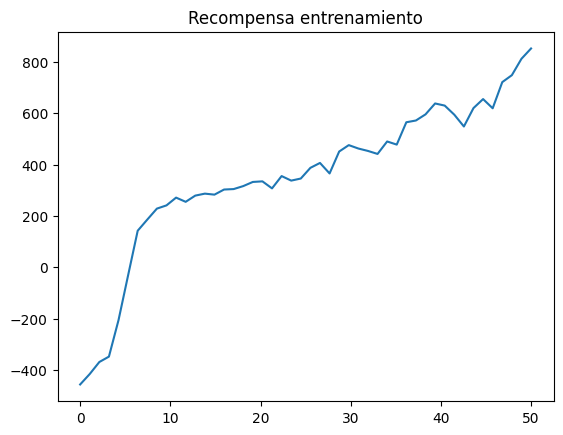

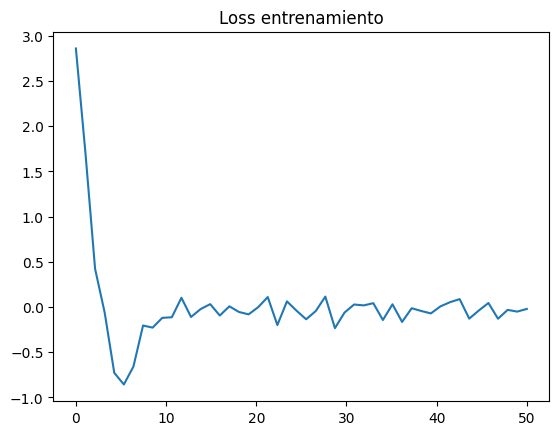

In [10]:
modelo_entrenado = "PPO_Clip_Annealing v1"
PPO = PPO_Clip_Basic(hiperparams )
save_policy_file = f"trained_net/{modelo_entrenado}/flappy_actor.pth"
save_value_file = f"trained_net/{modelo_entrenado}/flappy_critic.pth"
save_metric_file = f"trained_net/{modelo_entrenado}/metrics.pt"
rewards, loss, entropy = PPO.train(env, save_file_policy=save_policy_file, save_file_value=save_value_file, save_metrics_file=save_metric_file)
plot_metrics(modelo_entrenado, hiperparams)


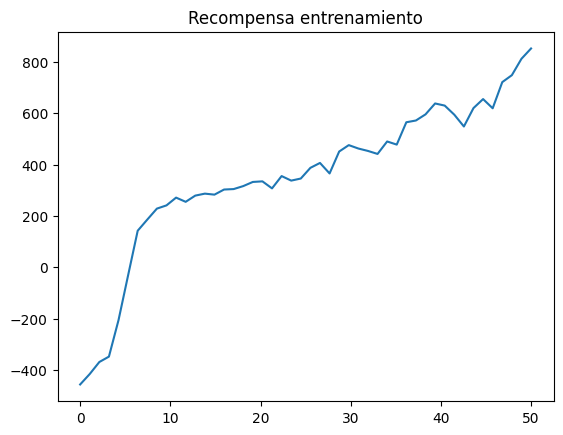

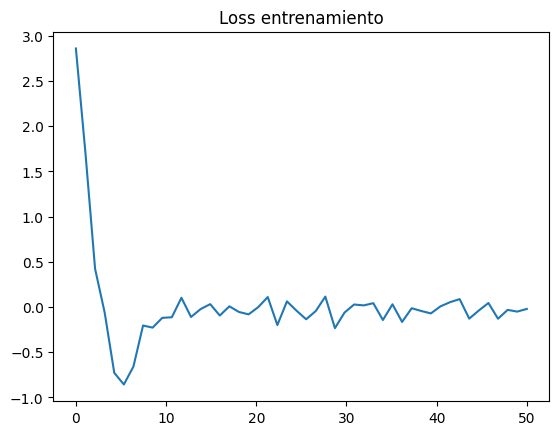

reward: 13.69999999999997 en 130 pasos
reward: 36.40000000000021 en 312 pasos
reward: 8.399999999999986 en 86 pasos


In [11]:
modelo_entrenado = "PPO_Clip_Annealing v1"
env = gymnasium.make("FlappyBird-v0", render_mode="human", use_lidar=False)
PPO = PPO_Clip_Basic(hiperparams )
plot_metrics(modelo_entrenado, hiperparams) 

policy_net = PolicyNet(12, 2)

policy_net.load_state_dict(torch.load(f"trained_net/{modelo_entrenado}/flappy_actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()



## Completo

In [12]:
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)
hiperparams = {
    "epochs": 50, #dejar 1500,
    "K": 80,
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.0001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 60000
    
}

Epoch 1/50 -- reward: -486.60
Guardando modelos...
Epoch 2/50 -- reward: -448.80
Guardando modelos...
Epoch 3/50 -- reward: -409.80
Guardando modelos...
Epoch 4/50 -- reward: -309.60
Guardando modelos...
Epoch 5/50 -- reward: -214.90
Guardando modelos...
Epoch 6/50 -- reward: 8.80
Guardando modelos...
Epoch 7/50 -- reward: 135.40
Guardando modelos...
Epoch 8/50 -- reward: 184.80
Guardando modelos...
Epoch 9/50 -- reward: 215.10
Guardando modelos...
Epoch 10/50 -- reward: 229.10
Guardando modelos...
Epoch 11/50 -- reward: 255.00
Guardando modelos...
Epoch 12/50 -- reward: 271.10
Guardando modelos...
Epoch 13/50 -- reward: 253.20
Epoch 14/50 -- reward: 280.10
Guardando modelos...
Epoch 15/50 -- reward: 284.20
Guardando modelos...
Epoch 16/50 -- reward: 303.10
Guardando modelos...
Epoch 17/50 -- reward: 306.30
Guardando modelos...
Epoch 18/50 -- reward: 304.80
Epoch 19/50 -- reward: 357.30
Guardando modelos...
Epoch 20/50 -- reward: 322.70
Epoch 21/50 -- reward: 343.00
Epoch 22/50 -- rewa

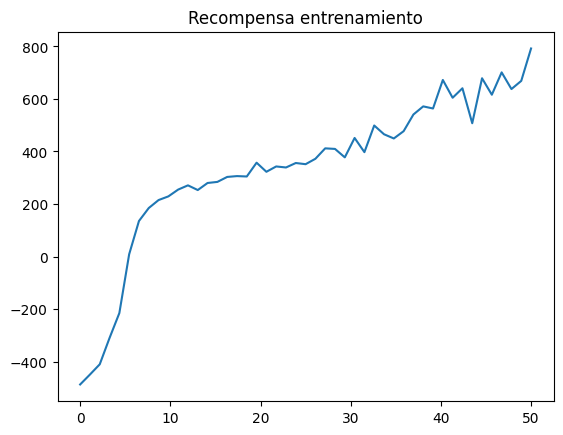

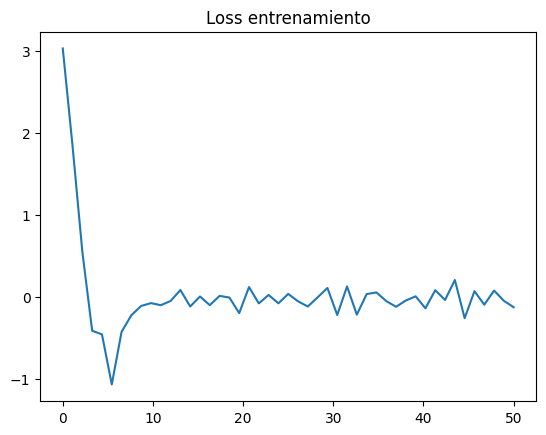

In [13]:
modelo_entrenado = "PPO_Clip_Completo v1"
PPO = PPO_Clip_Basic(hiperparams )
save_policy_file = f"trained_net/{modelo_entrenado}/flappy_actor.pth"
save_value_file = f"trained_net/{modelo_entrenado}/flappy_critic.pth"
save_metric_file = f"trained_net/{modelo_entrenado}/metrics.pt"
rewards, loss, entropy = PPO.train(env, save_file_policy=save_policy_file, save_file_value=save_value_file, save_metrics_file=save_metric_file)
plot_metrics(modelo_entrenado, hiperparams)


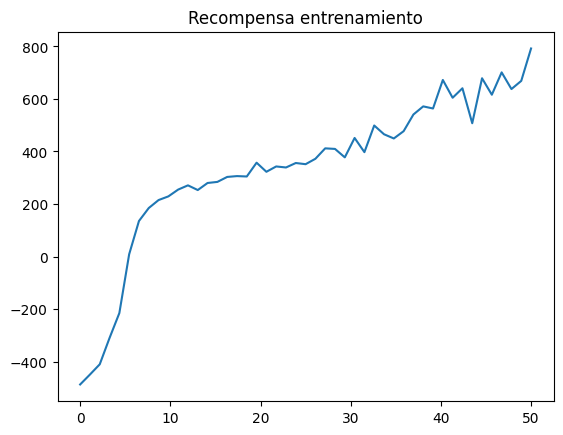

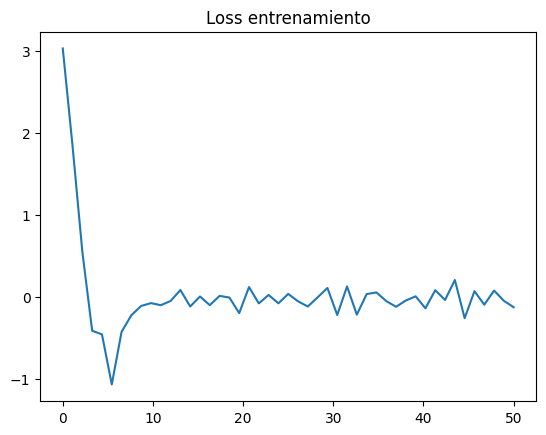

reward: 8.399999999999986 en 86 pasos
reward: 32.40000000000017 en 281 pasos
reward: 18.800000000000022 en 172 pasos


In [14]:
modelo_entrenado = "PPO_Clip_Completo v1"
env = gymnasium.make("FlappyBird-v0", render_mode="human", use_lidar=False)
PPO = PPO_Clip_Basic(hiperparams )
plot_metrics(modelo_entrenado, hiperparams) 

policy_net = PolicyNet(12, 2)

policy_net.load_state_dict(torch.load(f"trained_net/{modelo_entrenado}/flappy_actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()

